In [1]:
import pandas as pd
import numpy as np
import sklearn.model_selection as train_test_split
from openpyxl import load_workbook
from pathlib import Path
import io
import matplotlib
import seaborn as sns   
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
import sklearn.svm as svm
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler   
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression 
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score




In [2]:
df_exped = pd.read_csv('exped.csv')
df_exped.head()

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_6860\984487663.py:1: DtypeWarning: Columns (8,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_exped = pd.read_csv('exped.csv')


,expid,peakid,year,season,host,route1,route2,route3,route4,nation,...,accidents,achievment,agency,comrte,stdrte,primrte,primmem,primref,primid,chksum
0,ANN260101,ANN2,1960,Spring,Nepal,NW Ridge-W Ridge,NaN,NaN,NaN,UK,...,NaN,NaN,NaN,False,False,False,False,False,NaN,2442047
1,ANN269301,ANN2,1969,Autumn,Nepal,NW Ridge-W Ridge,NaN,NaN,NaN,Yugoslavia,...,Draslar frostbitten hands and feet,NaN,NaN,False,False,False,False,False,NaN,2445501
2,ANN273101,ANN2,1973,Spring,Nepal,W Ridge-N Face,NaN,NaN,NaN,Japan,...,NaN,NaN,NaN,False,False,False,False,False,NaN,2446797
3,ANN278301,ANN2,1978,Autumn,Nepal,N Face-W Ridge,NaN,NaN,NaN,UK,...,NaN,NaN,NaN,False,False,False,False,False,NaN,2448822
4,ANN279301,ANN2,1979,Autumn,Nepal,N Face-W Ridge,NW Ridge of A-IV,NaN,NaN,UK,...,NaN,NaN,NaN,False,False,False,False,False,NaN,2449204


In [3]:

class info_modulo():
    def __init__(self, data):
        # inicialización
        self.data = data

    # Crear un dataframe para la df.info()
    def frame_info(self, data):
        buf = io.StringIO()
        data.info(buf=buf)
        s = buf.getvalue()
        lines = [line.split() for line in s.splitlines()[3:-2]]
        return pd.DataFrame(lines)

    def variables_null(self):
        null_columns = self.data.columns[self.data.isnull().any()]
        df_2 = pd.DataFrame(columns=['Nombre Variable', 'Cantidad de Nulos'])
        for col in null_columns:
            nueva_fila = {
                'Nombre Variable': col,
                'Cantidad de Nulos': self.data[col].isnull().sum()
            }
            df_2 = pd.concat([df_2, pd.DataFrame([nueva_fila])], ignore_index=True)
        return df_2

    def variables_nan(self):
        obj_df = self.data.select_dtypes(include=['object'])
        nan_columns = [col for col in obj_df.columns if obj_df[col].isnull().any() or (obj_df[col] == '').any()]
        df_2 = pd.DataFrame(columns=['Nombre Variable', 'Cantidad de Nan o vacíos'])
        for col in nan_columns:
            cantidad = obj_df[col].isnull().sum() + (obj_df[col] == '').sum()
            nueva_fila = {
                'Nombre Variable': col,
                'Cantidad de Nan o vacíos': cantidad
            }
            df_2 = pd.concat([df_2, pd.DataFrame([nueva_fila])], ignore_index=True)
        return df_2

    def info_dataframe(self, ruta = ''):
        print(f"Tamaño: {self.data.shape}")
        print("\n")
        print(f"Variables nulos: ")
        print(self.variables_null())
        print("\n")
        print(f"Variables NAN: ")
        print(self.variables_nan())
        print("\n")    
        print(f"Informacion dataframe: ")
        print(self.data.info())
        print("\n")
        print(f"Datos: ")
        print(self.data.head(10))
        print("\n")
        

In [4]:
class depurar_dataset:
    def __init__(self, data, target_column):
        self.data = data.copy()
        self.target_column = target_column
        self.columnas_eliminadas = []
        self.columnas_imputadas = {}
        self.columnas_codificadas = []

    def codificar_categoricas(self):
        categoricas = self.data.drop(columns=[self.target_column], errors='ignore').select_dtypes(include=['object', 'category']).columns
        for col in categoricas:
            self.data[col] = self.data[col].astype(str).fillna("MISSING")
            self.data[col] = LabelEncoder().fit_transform(self.data[col])
            self.columnas_codificadas.append(col)

    def imputar_o_eliminar_nulos(self, porcnull_aceptable=30, metodo='METKNN'):
        columnas_con_nulos = self.data.drop(columns=[self.target_column], errors='ignore').columns[self.data.drop(columns=[self.target_column], errors='ignore').isnull().any()]
        for col in columnas_con_nulos:
            porcentaje = 100 * self.data[col].isnull().sum() / self.data.shape[0]
            if porcentaje >= porcnull_aceptable:
                self.data.drop(col, axis=1, inplace=True)
                self.columnas_eliminadas.append(col)
            else:
                if metodo == 'METKNN':
                    imputer = KNNImputer(n_neighbors=5)
                    self.data[col] = imputer.fit_transform(self.data[[col]])
                    self.columnas_imputadas[col] = 'KNN'
                elif metodo == 'METMEDIA':
                    self.data[col] = SimpleImputer(strategy='mean').fit_transform(self.data[[col]])
                    self.columnas_imputadas[col] = 'Media'
                elif metodo == 'METMODA':
                    self.data[col] = SimpleImputer(strategy='most_frequent').fit_transform(self.data[[col]])
                    self.columnas_imputadas[col] = 'Moda'
                else:
                    self.data.dropna(subset=[col], inplace=True)
                    self.columnas_eliminadas.append(col)

    def eliminar_alta_cardinalidad(self, umbral=30):
        cardinalidad = self.data.drop(columns=[self.target_column], errors='ignore').nunique() * 100 / self.data.shape[0]
        cols = cardinalidad[cardinalidad > umbral].index.tolist()
        self.data.drop(columns=cols, inplace=True)
        self.columnas_eliminadas.extend(cols)

    def eliminar_baja_varianza(self, umbral=0.99):
        for col in self.data.drop(columns=[self.target_column], errors='ignore').columns:
            top_freq = self.data[col].value_counts(normalize=True).max()
            if top_freq > umbral:
                self.data.drop(col, axis=1, inplace=True)
                self.columnas_eliminadas.append(col)

    def eliminar_correlacionadas(self, umbral=0.75):
        corr = self.data.drop(columns=[self.target_column], errors='ignore').corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [col for col in upper.columns if any(upper[col] > umbral)]
        self.data.drop(columns=to_drop, inplace=True)
        self.columnas_eliminadas.extend(to_drop)

    def ejecutar(self, porcnull_aceptable=35, metodo='METKNN', cardinalidad=33, varianza=0.99, correlacion=0.9):
        self.codificar_categoricas()
        self.imputar_o_eliminar_nulos(porcnull_aceptable, metodo)
        self.eliminar_alta_cardinalidad(cardinalidad)
        self.eliminar_baja_varianza(varianza)
        self.eliminar_correlacionadas(correlacion)
        print(f"Columnas eliminadas: {self.columnas_eliminadas}")
        print(f"Columnas imputadas: {self.columnas_imputadas}")
        print(f"Columnas codificadas: {self.columnas_codificadas}")
        print(f"Shape final del DataFrame: {self.data.shape}")
        return self.data



In [5]:

class modelo_ml():
    def __init__(self, x, y):
        # inicialización
        self.x = x
        self.y = y
    
    def escalar_data(self, x, funcion):
        scaler = funcion
        X_scaled = scaler.fit_transform(x)
        return X_scaled

    def division_datos(self, tamano, seed_number, estratifica='NO'):
        if (estratifica.upper() == 'NO'):
            X_train, X_test, y_train, y_test = train_test_split(self.x, self.y, test_size=tamano, random_state=seed_number)
        else:
            X_train, X_test, y_train, y_test = train_test_split(self.x, self.y, test_size=tamano, random_state=seed_number, stratify=self.y)
        return X_train, X_test, y_train, y_test
    
    def matriz_confusion(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title('Matriz de Confusión')
        plt.show()

    def entrenar_modelo(self, modelo, seed_number, funcion_escalado, estimador='mean_squared_error', tamano=0.2, escalar='NO', tipo='REGRESION', estratifica='NO'):
        X_train, X_test, y_train, y_test = modelo_ml.division_datos(self, tamano, seed_number, estratifica)
        # Necesitamos escalar?
        if (escalar.upper() == 'SI'):
            X_train_escalada = modelo_ml.escalar_data(self, X_train, funcion_escalado)
            X_test_escalada = modelo_ml.escalar_data(self, X_test, funcion_escalado)
        else:
            X_train_escalada = X_train
            X_test_escalada = X_test

        model_train = modelo.fit(X_train_escalada, y_train)
        y_pred_train = model_train.predict(X_train_escalada)
        y_pred = model_train.predict(X_test_escalada)

        if (tipo.upper() == 'CLASIFICACION'):
            if estimador == 'accuracy':
                train_score = accuracy_score(y_train, y_pred_train)
                test_score = accuracy_score(y_test, y_pred)
            elif estimador == 'recall':
                train_score = recall_score(y_train, y_pred_train)
                test_score = recall_score(y_test, y_pred)
            elif estimador == 'f1_score':
                train_score = f1_score(y_train, y_pred_train)
                test_score = f1_score(y_test, y_pred)
            elif estimador == 'roc':
                train_score = roc_auc_score(y_train, model_train.predict_proba(X_train_escalada)[:, 1])
                test_score = roc_auc_score(y_test, model_train.predict_proba(X_test_escalada)[:, 1])
            modelo_ml.matriz_confusion(self, y_test, y_pred)
        else:
            if estimador == 'mean_squared_error':
                train_score = mean_squared_error(y_train, y_pred_train)
                test_score = mean_squared_error(y_test, y_pred)
            elif estimador == 'mean_absolute_error':
                train_score = mean_absolute_error(y_train, y_pred_train)
                test_score = mean_absolute_error(y_test, y_pred)
            elif estimador == 'r2_score':
                train_score = r2_score(y_train, y_pred_train)
                test_score = r2_score(y_test, y_pred)

        print("Entrenamiento estimación : " , train_score)
        print("Entrenamiento score R2 :", model_train.score(X_train_escalada, y_train))
        print("Prueba estimación : ", test_score)
        print("Prueba score R2 :", model_train.score(X_test_escalada, y_test))

        return X_train, X_train_escalada, y_train, X_test, X_test_escalada, y_test, y_pred, train_score, test_score
    

In [6]:
df = pd.read_csv('exped.csv')
df.infomodulo = info_modulo(df)
df.infomodulo.info_dataframe()

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_6860\1632476098.py:1: DtypeWarning: Columns (8,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('exped.csv')


Tamaño: (11425, 65)


Variables nulos: 
   Nombre Variable Cantidad de Nulos
0           route1               150
1           route2             11065
2           route3             11395
3           route4             11420
4          leaders                24
5          sponsor               816
6          ascent1              8647
7          ascent2             11324
8          ascent3             11414
9          ascent4             11421
10       countries              7312
11        approach              5989
12          bcdate              1630
13         smtdate               755
14         smttime              6443
15         smtdays              1754
16         totdays              3019
17        termdate              2975
18        termnote              6777
19       othersmts              9226
20       campsites               379
21       accidents              8424
22      achievment             10449
23          agency              1729
24          primid             1067

In [7]:
df_exped = df.copy()
depurado = depurar_dataset(df_exped, 'success1')
target_column = 'success1'  # Reemplaza 'target_column' con el nombre real de tu columna objetivo
df_limpio = depurado.ejecutar(porcnull_aceptable=30, metodo='METKNN', cardinalidad=33, varianza=0.99, correlacion=0.9)

Columnas eliminadas: ['smttime', 'expid', 'leaders', 'sponsor', 'bcdate', 'smtdate', 'termnote', 'campsites', 'chksum', 'route3', 'route4', 'success3', 'success4', 'ascent2', 'ascent3', 'ascent4', 'claimed', 'disputed', 'traverse', 'parapente', 'o2unkwn', 'o2none', 'o2climb']
Columnas imputadas: {'smtdays': 'KNN', 'totdays': 'KNN'}
Columnas codificadas: ['expid', 'peakid', 'season', 'host', 'route1', 'route2', 'route3', 'route4', 'nation', 'leaders', 'sponsor', 'ascent1', 'ascent2', 'ascent3', 'ascent4', 'countries', 'approach', 'bcdate', 'smtdate', 'termdate', 'termreason', 'termnote', 'othersmts', 'campsites', 'accidents', 'achievment', 'agency', 'primid']
Shape final del DataFrame: (11425, 42)


In [8]:
df_limpio.infodataset = info_modulo(df_limpio)
df_limpio.infodataset.info_dataframe()

Tamaño: (11425, 42)


Variables nulos: 
Empty DataFrame
Columns: [Nombre Variable, Cantidad de Nulos]
Index: []


Variables NAN: 
Empty DataFrame
Columns: [Nombre Variable, Cantidad de Nan o vacíos]
Index: []


Informacion dataframe: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11425 entries, 0 to 11424
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   peakid      11425 non-null  int64  
 1   year        11425 non-null  int64  
 2   season      11425 non-null  int64  
 3   host        11425 non-null  int64  
 4   route1      11425 non-null  int64  
 5   route2      11425 non-null  int64  
 6   nation      11425 non-null  int64  
 7   success1    11425 non-null  bool   
 8   success2    11425 non-null  bool   
 9   ascent1     11425 non-null  int64  
 10  countries   11425 non-null  int64  
 11  approach    11425 non-null  int64  
 12  smtdays     11425 non-null  float64
 13  totdays     11425 non-null  float64


In [9]:
df_limpio.corr().style.background_gradient(cmap ='coolwarm')

,peakid,year,season,host,route1,route2,nation,success1,success2,ascent1,countries,approach,smtdays,totdays,termdate,termreason,highpoint,ski,camps,rope,totmembers,smtmembers,mdeaths,tothired,smthired,hdeaths,nohired,o2used,o2descent,o2sleep,o2medical,o2taken,othersmts,accidents,achievment,agency,comrte,stdrte,primrte,primmem,primref,primid
peakid,1.000000,-0.095297,0.017646,0.255519,-0.145463,-0.040464,-0.029260,-0.097259,0.044514,-0.082528,0.055943,-0.066913,-0.003991,-0.004862,0.031759,-0.053522,-0.092020,0.027333,-0.060205,0.046212,-0.014907,-0.074247,0.018515,-0.042602,-0.072529,-0.002714,0.062213,-0.028378,-0.000281,-0.070269,-0.012041,-0.024148,-0.055561,0.027254,-0.034427,0.056411,-0.431306,-0.076901,0.094935,0.107699,0.159544,-0.126310
year,-0.095297,1.000000,-0.077698,-0.001705,0.031026,0.079673,-0.064760,0.131892,-0.018636,0.297337,-0.158979,-0.104067,-0.142109,-0.141976,0.417011,0.133058,0.074798,0.026273,-0.043391,-0.020900,-0.117429,0.117817,-0.114810,0.016087,0.245966,-0.083415,-0.071550,0.181648,0.023444,0.114363,-0.029941,-0.000407,0.226464,0.218100,0.078562,-0.351474,0.301240,0.254446,-0.182524,-0.326450,-0.220864,0.140807
season,0.017646,-0.077698,1.000000,-0.003954,-0.101010,-0.006513,0.043985,-0.017648,0.003881,-0.038125,0.022088,0.036736,0.195661,0.200630,-0.064194,-0.008230,0.081164,-0.042878,0.082688,0.044040,-0.006246,-0.029746,0.016645,0.070536,0.027559,0.020167,-0.031336,0.135533,0.010309,0.160909,0.012531,-0.031197,-0.018831,-0.052610,-0.053506,0.034940,-0.029806,0.139068,0.018202,0.028366,0.034263,-0.039814
host,0.255519,-0.001705,-0.003954,1.000000,0.284068,0.001602,0.025599,-0.043851,0.021417,-0.039415,0.006529,0.010380,-0.158982,-0.187030,0.082655,-0.024310,-0.230214,-0.056725,-0.041480,0.046745,-0.018923,-0.027686,0.020887,0.011317,-0.017215,0.028285,-0.019692,-0.179945,-0.020113,-0.122297,-0.041491,-0.037446,-0.100344,0.052828,-0.000807,0.054406,-0.405080,-0.405835,0.059689,0.060205,0.088191,-0.069748
route1,-0.145463,0.031026,-0.101010,0.284068,1.000000,0.034865,0.025904,0.075735,0.018458,-0.083760,-0.012637,0.080734,-0.221669,-0.232216,0.062623,0.091187,-0.195894,-0.042019,-0.126447,0.006942,-0.024453,0.038237,-0.038488,-0.072273,-0.044533,-0.011087,0.005795,-0.211006,-0.038298,-0.135177,-0.027656,-0.012976,-0.059810,0.023825,0.008593,-0.019258,-0.016448,-0.341730,0.038188,0.020694,0.058508,-0.036929
route2,-0.040464,0.079673,-0.006513,0.001602,0.034865,1.000000,-0.017574,0.081054,-0.531329,-0.021116,0.018254,-0.019019,-0.058842,-0.064600,0.055806,0.015104,-0.020634,0.005311,0.009292,0.010118,-0.068354,-0.012368,-0.040288,-0.029992,0.022355,-0.007678,-0.059615,0.011737,-0.023564,0.023941,-0.017726,0.012516,0.020771,0.035612,0.014549,-0.042174,0.103406,0.060222,-0.013514,-0.010300,-0.025987,0.020577
nation,-0.029260,-0.064760,0.043985,0.025599,0.025904,-0.017574,1.000000,0.018444,0.014747,-0.015224,-0.128909,0.052547,0.071623,0.082730,-0.022665,0.024429,0.003932,0.003049,0.024972,0.030715,0.029214,0.017930,-0.014258,0.015848,0.005951,0.005226,0.020643,0.045598,0.018880,0.040563,0.000396,-0.000974,-0.059303,-0.015663,0.001917,0.005938,-0.001723,-0.016264,0.051590,0.053314,0.062112,-0.069104
success1,-0.097259,0.131892,-0.017648,-0.043851,0.075735,0.081054,0.018444,1.000000,-0.005250,-0.412080,-0.129022,0.006159,0.127484,0.080718,0.099186,0.822128,0.440267,0.045887,0.279840,-0.010853,0.144470,0.570986,-0.030252,0.168754,0.375597,-0.053712,-0.149028,0.321645,0.040431,0.239531,0.009163,-0.106872,-0.012201,0.025049,-0.136054,-0.055939,0.216044,0.118601,0.005106,-0.006884,0.019316,-0.022739
success2,0.044514,-0.018636,0.003881,0.021417,0.018458,-0.531329,0.014747,-0.005250,1.000000,0.000454,-0.012043,0.023166,0.037402,0.032331,-0.010164,0.089877,0.045334,-0.009987,0.026454,-0.006068,0.070575,0.096071,0.002531,0.051292,0.019112,-0.007455,0.018492,0.032034,0.023839,0.003249,0.005693,-0.022096,-0.019536,-0.000746,-0.015210,0.016910,-0.085169,-0.027365,0.038991,0.017264,0.064898,-0.059271
ascent1,-0.082

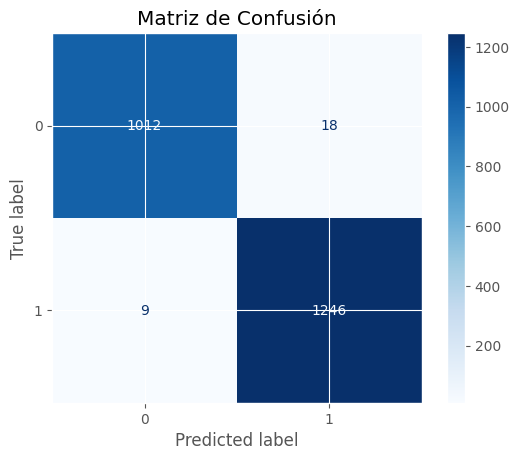

Entrenamiento estimación :  0.9919037199124726
Entrenamiento score R2 : 0.9919037199124726
Prueba estimación :  0.9881838074398249
Prueba score R2 : 0.9881838074398249


In [10]:
from sklearn.linear_model import LogisticRegression

X, y = df_limpio.drop(target_column, axis=1), df_limpio[target_column]
funcion_escalado = StandardScaler()
modelo = LogisticRegression(max_iter=1000)
seed_number = 42
tamano = 0.2
estimador = 'accuracy'  # Para clasificación
ml_modelo = modelo_ml(X, y)
# Entrenamiento del modelo de clasificación
regresionlogistica = ml_modelo.entrenar_modelo(modelo, seed_number, funcion_escalado, estimador, tamano, escalar='SI', tipo='CLASIFICACION', estratifica='SI')
X_train, X_train_escalada, y_train, X_test, X_test_escalada, y_test, y_pred, train_score, test_score = regresionlogistica   

In [11]:
# Entrenamiento modelo PCA con escalado de los datos
# ==============================================================================
pca_pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA())
])
pca_pipe.fit(X)

# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']
print(modelo_pca)

PCA()


In [12]:
# Pipeline con modelo
pca_pipe1 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('regressor', LinearRegression())
])

# GridSearch sobre número de componentes
param_grid = {'pca__n_components': [5,10, 15, 20, 25, 30]}

grid = GridSearchCV(
    estimator=pca_pipe1,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    refit=True
)

grid.fit(X_train, y_train)
print("Mejores parámetros:", grid.best_params_)
print("Mejor score:", grid.best_score_)
print("Mejor estimador:", grid.best_estimator_)


Mejores parámetros: {'pca__n_components': 30}
Mejor score: -0.05438727524183765
Mejor estimador: Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=30)),
                ('regressor', LinearRegression())])


In [14]:

y_predGrid = grid.best_estimator_.predict(X)
print('R2 score:', r2_score(y, y_predGrid))

R2 score: 0.7801086660995471
